# Phase 6: SHAP Explainability

**Goal:** Understand *why* the model makes each prediction. Banks and regulators require explainability — SHAP (SHapley Additive exPlanations) is the industry standard.

- **Global explanation:** which features matter most across all predictions?
- **Local explanation:** why did this specific borrower get a high/low score?

In [1]:
import sys
sys.path.append('..')

import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap

from src.data.loader import load_raw
from src.features.engineer import engineer, split, FEATURES

In [2]:
with open('../models/xgboost.pkl', 'rb') as f:
    model = pickle.load(f)

df = engineer(load_raw())
X_train, X_test, y_train, y_test = split(df)

# Use a sample for speed — SHAP on 30k rows is slow
X_sample = X_test.sample(2000, random_state=42)
print(f"Explaining {len(X_sample):,} test examples")

Explaining 2,000 test examples


## 1. Compute SHAP Values

`TreeExplainer` is exact and fast for tree-based models. It computes each feature's marginal contribution to every prediction.

In [3]:
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_sample)
print(f"SHAP values shape: {shap_values.shape}")

SHAP values shape: (2000, 13)


## 2. Global Feature Importance — Bar Plot

Mean absolute SHAP value per feature = average impact on the model output.

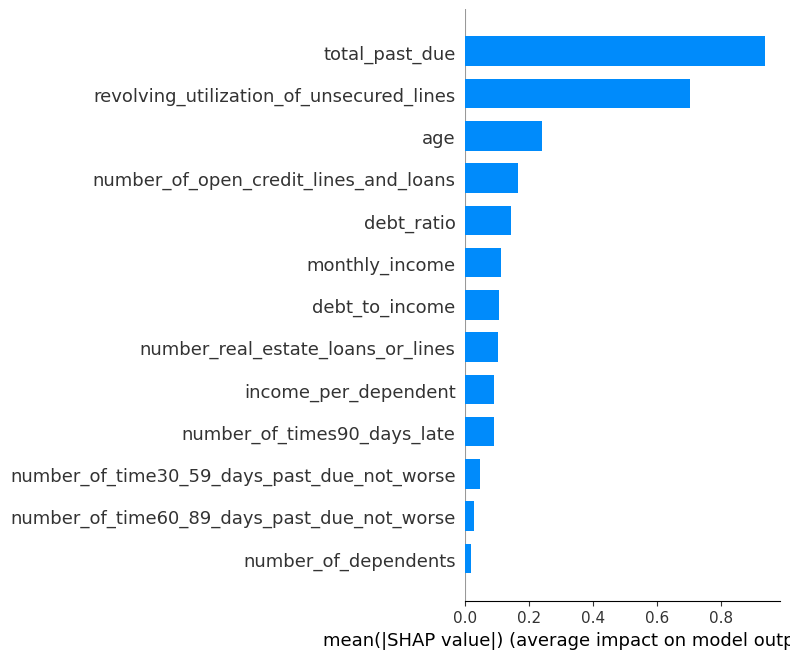

In [4]:
shap.summary_plot(shap_values, X_sample, plot_type='bar', show=True)

## 3. Beeswarm Plot

Shows **direction** of impact: red = high feature value, blue = low. A red dot on the right means high feature value increases default probability.

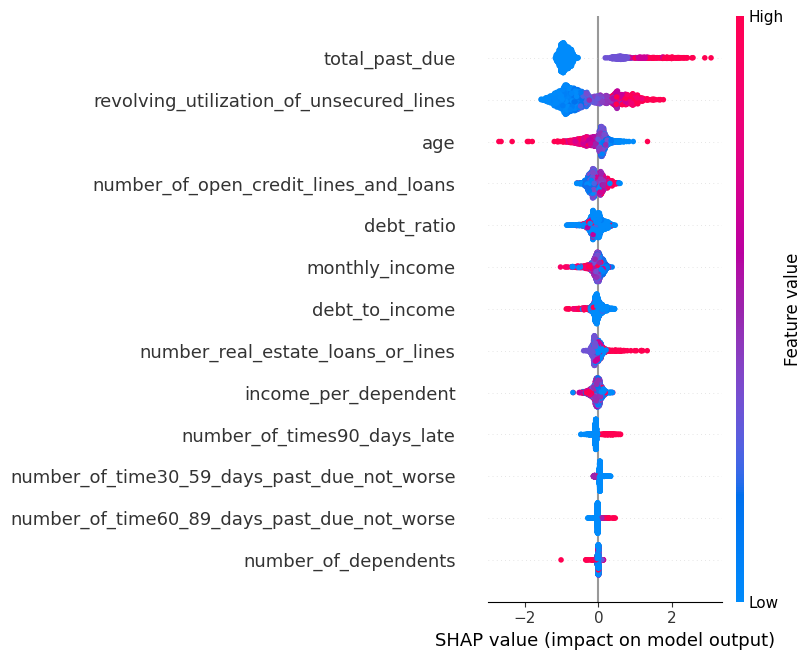

In [5]:
shap.summary_plot(shap_values, X_sample, show=True)

## 4. Single Prediction — Waterfall Plot

Pick the highest-risk borrower in the sample and explain why they received a high default probability.

Highest risk borrower — P(default) = 0.9864


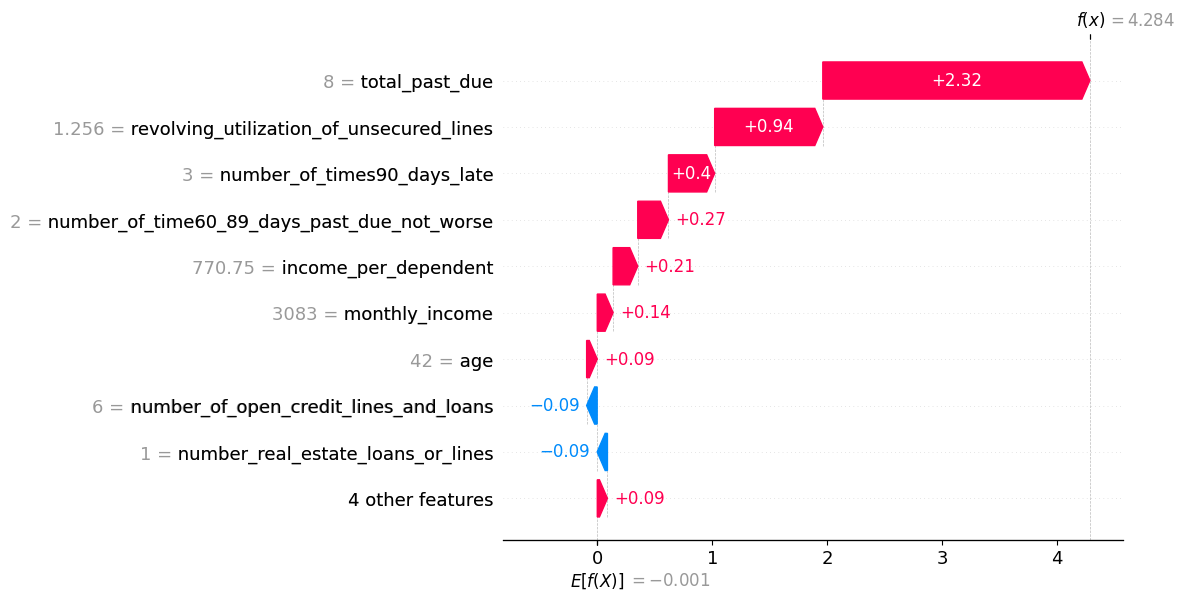

In [6]:
probs = model.predict_proba(X_sample)[:, 1]
highest_risk_idx = np.argmax(probs)
print(f"Highest risk borrower — P(default) = {probs[highest_risk_idx]:.4f}")

shap_explanation = explainer(X_sample)
shap.plots.waterfall(shap_explanation[highest_risk_idx], show=True)

## 5. Dependence Plot

How does revolving utilization affect default probability, and does it interact with total past due events?

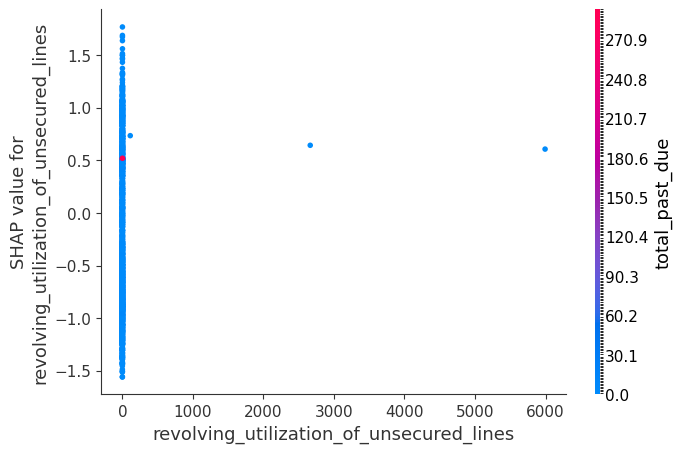

In [7]:
shap.dependence_plot(
    'revolving_utilization_of_unsecured_lines',
    shap_values,
    X_sample,
    interaction_index='total_past_due',
    show=True
)